# Step 5: Decision Tree

This notebook trains, evaluates, and interprets a **single Decision Tree classifier**
for predicting whether a user will reorder a given product in their next order.

## Role in the Project
The decision tree occupies a deliberate position in the model lineup:

| Model | Type | Key Strength |
|---|---|---|
| Logistic Regression (Step 4) | Linear baseline | Interpretable coefficients, fast |
| **Decision Tree (Step 5)** | **Non-linear, single tree** | **Human-readable decision logic** |
| LightGBM (Step 6) | Gradient boosting ensemble | Highest predictive performance |

Unlike Logistic Regression, a decision tree can capture non-linear relationships
and feature interactions without manual engineering. Unlike LightGBM, a single tree
can be visualised and read as a flowchart — every prediction can be traced back to
an explicit sequence of if/else rules. This interpretability makes it uniquely
valuable even if its predictive performance sits between the other two models.

## Prerequisites
- Steps 1-3 notebook must have been run first
- Step 4 (Logistic Regression) must have been run first — results are loaded for comparison
- Virtual environment must be active with dependencies installed

## Inputs (from Steps 1-3)

| File | Contents |
|---|---|
| `X_train_scaled.parquet` | StandardScaler-transformed training features (29 cols) |
| `X_test_scaled.parquet` | StandardScaler-transformed test features |
| `y_train.parquet` | Training labels |
| `y_test.parquet` | Test labels |
| `feature_cols.pkl` | Canonical feature list |

> **Note:** We use the scaled features (same as Logistic Regression) rather than
> the raw features. Decision trees are scale-invariant so scaling does not affect
> the tree structure or predictions -- but using the same feature set as Logistic
> Regression makes the Step 7 comparison cleaner and more consistent.

## Inputs (from Step 4)

| File | Contents |
|---|---|
| `lr_results.csv` | Logistic Regression metrics -- used as one benchmark |

## Roadmap
1. Load artefacts
2. Define feature set (same exclusions as Logistic Regression)
3. Depth analysis -- find the optimal tree depth
4. Train and tune the decision tree
5. Evaluate -- threshold-independent and threshold-dependent metrics
6. Visualise and interpret the tree
7. Feature importance
8. Save model and results


## 0. Imports & Configuration

In [1]:
import os, warnings, joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import (DecisionTreeClassifier, plot_tree,
                           export_text)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.6f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

RANDOM_STATE = 42

# ── Paths ─────────────────────────────────────────────────────────────────────
ARTEFACT_DIR = "../prepared_data"
MODEL_DIR    = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

print(f"ARTEFACT_DIR : {os.path.abspath(ARTEFACT_DIR)}")
print(f"MODEL_DIR    : {os.path.abspath(MODEL_DIR)}")


ARTEFACT_DIR : /Users/martinmilon/Documents/DTSC870/prepared_data
MODEL_DIR    : /Users/martinmilon/Documents/DTSC870/models


## 1. Load Artefacts

In [2]:
X_train_scaled = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_train_scaled.parquet'))
X_test_scaled  = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'X_test_scaled.parquet'))
y_train        = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_train.parquet'))['reordered']
y_test         = pd.read_parquet(os.path.join(ARTEFACT_DIR, 'y_test.parquet'))['reordered']
FEATURE_COLS   = joblib.load(os.path.join(ARTEFACT_DIR, 'feature_cols.pkl'))

# benchmark from Step 4
lr_results = pd.read_csv(os.path.join(MODEL_DIR, 'lr_results.csv'))

print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")
print(f"y_train        : {y_train.shape}  |  positive rate: {y_train.mean()*100:.1f}%")
print(f"y_test         : {y_test.shape}   |  positive rate: {y_test.mean()*100:.1f}%")
print(f"Features       : {len(FEATURE_COLS)}")
print(f"NaNs X_train   : {X_train_scaled.isnull().sum().sum()}")
print(f"NaNs X_test    : {X_test_scaled.isnull().sum().sum()}")

print(f"\nLogistic Regression benchmark (Step 4):")
print(f"  ROC-AUC  : {lr_results['ROC-AUC'].values[0]:.4f}")
print(f"  PR-AUC   : {lr_results['PR-AUC (Avg Prec)'].values[0]:.4f}")
print(f"  Brier    : {lr_results['Brier Score'].values[0]:.4f}")
print(f"  F1       : {lr_results['F1 (optimal thresh)'].values[0]:.4f}")


X_train_scaled : (1107416, 29)
X_test_scaled  : (277201, 29)
y_train        : (1107416,)  |  positive rate: 59.9%
y_test         : (277201,)   |  positive rate: 59.9%
Features       : 29
NaNs X_train   : 0
NaNs X_test    : 0

Logistic Regression benchmark (Step 4):
  ROC-AUC  : 0.9689
  PR-AUC   : 0.9841
  Brier    : 0.0472
  F1       : 0.9520


## 2. Define Feature Set

The decision tree uses the same feature exclusions as Logistic Regression:
- `aisle_id` excluded (not statistically significant, no ordinal meaning)
- `up_avg_add_to_cart` and `up_orders_since_last` excluded (caused near-perfect
  linear separation in Step 4; Step 6 feature importance confirmed they are not
  among the top predictors by gain, so exclusion is appropriate)

This makes the Step 7 three-way comparison consistent -- all models are evaluated
on the same effective feature set.


In [3]:
EXCLUDE_COLS = ['aisle_id', 'up_avg_add_to_cart', 'up_orders_since_last']
FEATURE_COLS_DT = [c for c in FEATURE_COLS if c not in EXCLUDE_COLS]

X_tr = X_train_scaled[FEATURE_COLS_DT]
X_te = X_test_scaled[FEATURE_COLS_DT]

print(f"Features used for Decision Tree : {len(FEATURE_COLS_DT)}")
print(f"Features excluded               : {EXCLUDE_COLS}")


Features used for Decision Tree : 26
Features excluded               : ['aisle_id', 'up_avg_add_to_cart', 'up_orders_since_last']


## 3. Depth Analysis

An unconstrained decision tree will overfit by memorising the training data --
it can keep splitting until every leaf contains a single row. We need to find
the right `max_depth` that balances training accuracy against generalisation.

We evaluate cross-validated ROC-AUC across a range of depths and look for the
point where validation performance plateaus or begins to decline.


Evaluating depths 2-20...

Best depth by CV AUC : 9
CV AUC at best depth : 0.9691


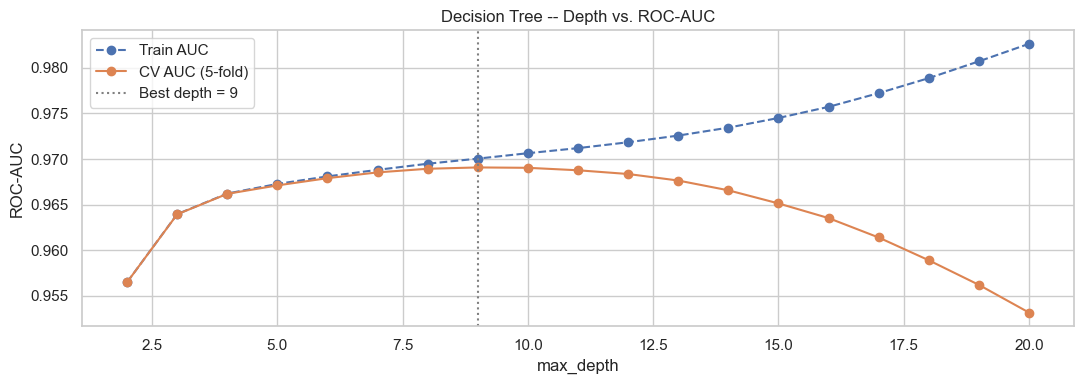

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
depths   = list(range(2, 21))
cv_aucs  = []
tr_aucs  = []

print("Evaluating depths 2-20...")
for depth in depths:
    dt = DecisionTreeClassifier(
        max_depth        = depth,
        class_weight     = 'balanced',
        random_state     = RANDOM_STATE
    )
    scores = cross_val_score(dt, X_tr, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_aucs.append(scores.mean())

    dt.fit(X_tr, y_train)
    tr_aucs.append(roc_auc_score(y_train, dt.predict_proba(X_tr)[:, 1]))

best_depth = depths[np.argmax(cv_aucs)]
print(f"\nBest depth by CV AUC : {best_depth}")
print(f"CV AUC at best depth : {max(cv_aucs):.4f}")

plt.figure(figsize=(11, 4))
plt.plot(depths, tr_aucs, 'o--', color='#4C72B0', label='Train AUC')
plt.plot(depths, cv_aucs, 'o-',  color='#DD8452', label='CV AUC (5-fold)')
plt.axvline(best_depth, linestyle=':', color='grey',
            label=f'Best depth = {best_depth}')
plt.xlabel('max_depth')
plt.ylabel('ROC-AUC')
plt.title('Decision Tree -- Depth vs. ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()


## 4. Train the Decision Tree

We train two versions:
- **Best-depth tree:** uses the depth identified by cross-validation -- optimised for performance
- **Shallow tree (depth=5):** a deliberately simplified version for visualisation and interpretation

Both are evaluated in Section 5. The shallow tree is not expected to match
the best-depth tree on metrics -- its purpose is interpretability.


In [5]:
# ── Best-depth tree ──────────────────────────────────────────────────────────
dt_best = DecisionTreeClassifier(
    max_depth    = best_depth,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
dt_best.fit(X_tr, y_train)

y_prob_best  = dt_best.predict_proba(X_te)[:, 1]
auc_best     = roc_auc_score(y_test, y_prob_best)

print(f"Best-depth tree (depth={best_depth}) trained.")
print(f"  Nodes       : {dt_best.tree_.node_count:,}")
print(f"  Leaves      : {dt_best.get_n_leaves():,}")
print(f"  Test ROC-AUC: {auc_best:.4f}")

# ── Shallow tree (depth=5) ────────────────────────────────────────────────────
dt_shallow = DecisionTreeClassifier(
    max_depth    = 5,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
dt_shallow.fit(X_tr, y_train)

y_prob_shallow = dt_shallow.predict_proba(X_te)[:, 1]
auc_shallow    = roc_auc_score(y_test, y_prob_shallow)

print(f"\nShallow tree (depth=5) trained.")
print(f"  Nodes       : {dt_shallow.tree_.node_count:,}")
print(f"  Leaves      : {dt_shallow.get_n_leaves():,}")
print(f"  Test ROC-AUC: {auc_shallow:.4f}")
print(f"\nUsing best-depth tree for all evaluation metrics.")


Best-depth tree (depth=9) trained.
  Nodes       : 461
  Leaves      : 231
  Test ROC-AUC: 0.9685

Shallow tree (depth=5) trained.
  Nodes       : 35
  Leaves      : 18
  Test ROC-AUC: 0.9669

Using best-depth tree for all evaluation metrics.


## 5. Evaluation

### 5.1 Threshold-Independent Metrics


In [6]:
roc_auc  = roc_auc_score(y_test, y_prob_best)
avg_prec = average_precision_score(y_test, y_prob_best)
brier    = brier_score_loss(y_test, y_prob_best)

lr_auc   = lr_results['ROC-AUC'].values[0]
lr_prec  = lr_results['PR-AUC (Avg Prec)'].values[0]
lr_brier = lr_results['Brier Score'].values[0]

print("Threshold-Independent Metrics (Test Set)")
print(f"{'Metric':<32} {'Decision Tree':>14} {'Logistic Reg':>14} {'Delta':>10}")
print("-" * 72)
print(f"{'ROC-AUC':<32} {roc_auc:>14.4f} {lr_auc:>14.4f} {roc_auc-lr_auc:>+10.4f}")
print(f"{'PR-AUC (Avg Precision)':<32} {avg_prec:>14.4f} {lr_prec:>14.4f} {avg_prec-lr_prec:>+10.4f}")
print(f"{'Brier Score (lower=better)':<32} {brier:>14.4f} {lr_brier:>14.4f} {brier-lr_brier:>+10.4f}")


Threshold-Independent Metrics (Test Set)
Metric                            Decision Tree   Logistic Reg      Delta
------------------------------------------------------------------------
ROC-AUC                                  0.9685         0.9689    -0.0004
PR-AUC (Avg Precision)                   0.9834         0.9841    -0.0007
Brier Score (lower=better)               0.0466         0.0472    -0.0006


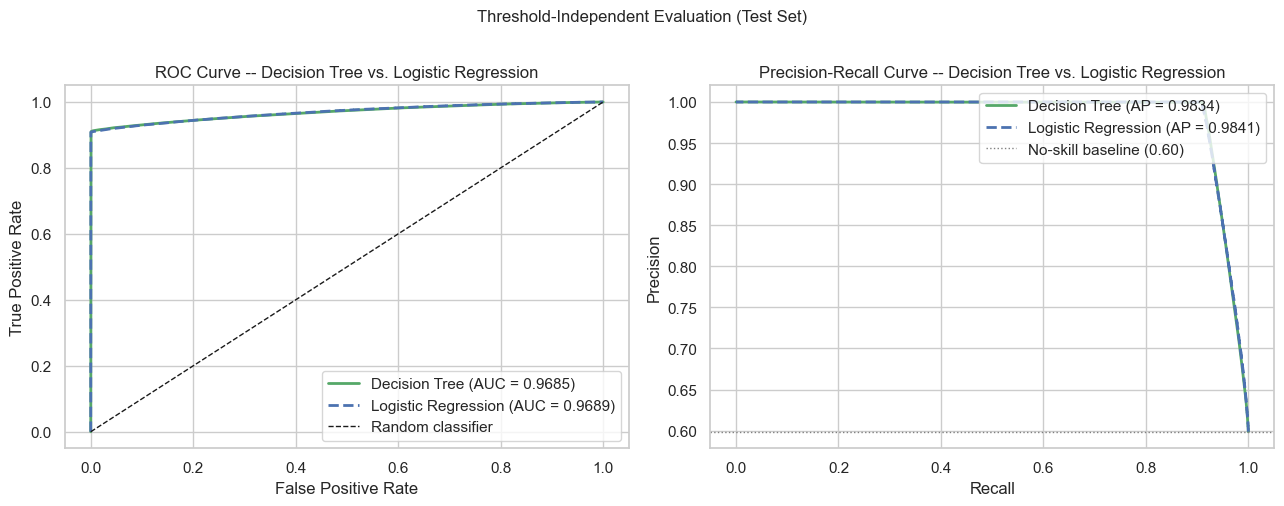

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lr_model = joblib.load(os.path.join(MODEL_DIR, 'lr_tuned.pkl'))
FEATURE_COLS_LR = [c for c in FEATURE_COLS if c not in ['aisle_id']]
y_prob_lr = lr_model.predict_proba(X_test_scaled[FEATURE_COLS_LR])[:, 1]

# ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_best)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

axes[0].plot(fpr_dt, tpr_dt, color='#55A868', lw=2,
             label=f'Decision Tree (AUC = {roc_auc:.4f})')
axes[0].plot(fpr_lr, tpr_lr, color='#4C72B0', lw=2, linestyle='--',
             label=f'Logistic Regression (AUC = {lr_auc:.4f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve -- Decision Tree vs. Logistic Regression')
axes[0].legend(loc='lower right')

# PR curves
prec_dt, rec_dt, _ = precision_recall_curve(y_test, y_prob_best)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
baseline = y_test.mean()

axes[1].plot(rec_dt, prec_dt, color='#55A868', lw=2,
             label=f'Decision Tree (AP = {avg_prec:.4f})')
axes[1].plot(rec_lr, prec_lr, color='#4C72B0', lw=2, linestyle='--',
             label=f'Logistic Regression (AP = {lr_prec:.4f})')
axes[1].axhline(baseline, linestyle=':', color='grey', lw=1,
                label=f'No-skill baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve -- Decision Tree vs. Logistic Regression')
axes[1].legend(loc='upper right')

plt.suptitle('Threshold-Independent Evaluation (Test Set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


### 5.2 Optimal Classification Threshold

Decision trees output probabilities based on the class distribution in each leaf
rather than a smooth sigmoid curve. This means their probability distributions
tend to be more discrete than Logistic Regression or LightGBM, which can make
threshold selection more sensitive.


Optimal threshold (max F1) : 0.5517
F1 at optimal threshold    : 0.9530


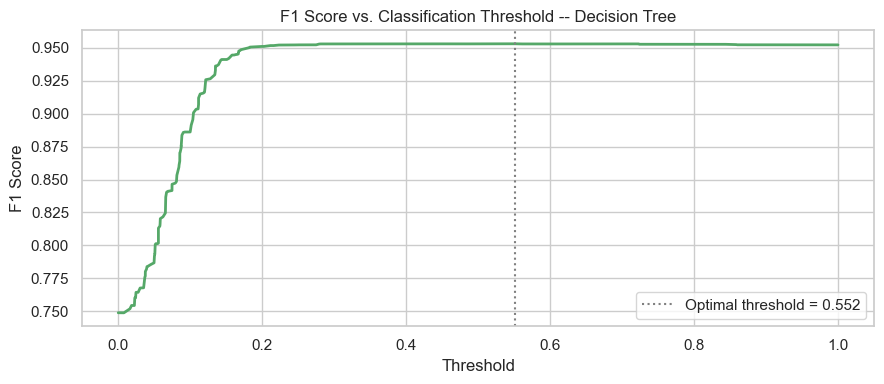

In [8]:
prec_t, rec_t, pr_thresh = precision_recall_curve(y_test, y_prob_best)
f1_scores      = 2 * prec_t[:-1] * rec_t[:-1] / (prec_t[:-1] + rec_t[:-1] + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = pr_thresh[best_idx]
best_f1        = f1_scores[best_idx]

print(f"Optimal threshold (max F1) : {best_threshold:.4f}")
print(f"F1 at optimal threshold    : {best_f1:.4f}")

plt.figure(figsize=(9, 4))
plt.plot(pr_thresh, f1_scores, color='#55A868', lw=2)
plt.axvline(best_threshold, linestyle=':', color='grey',
            label=f'Optimal threshold = {best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Classification Threshold -- Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 Threshold-Dependent Metrics

In [9]:
y_pred_05  = (y_prob_best >= 0.50).astype(int)
y_pred_opt = (y_prob_best >= best_threshold).astype(int)

print("Classification Report - Default Threshold (0.50)")
print(classification_report(y_test, y_pred_05,
                             target_names=['Not Reordered', 'Reordered']))

print(f"Classification Report - Optimal Threshold ({best_threshold:.3f})")
print(classification_report(y_test, y_pred_opt,
                             target_names=['Not Reordered', 'Reordered']))


Classification Report - Default Threshold (0.50)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.95    277201
 weighted avg       0.95      0.95      0.95    277201

Classification Report - Optimal Threshold (0.552)
               precision    recall  f1-score   support

Not Reordered       0.88      1.00      0.94    111269
    Reordered       1.00      0.91      0.95    165932

     accuracy                           0.95    277201
    macro avg       0.94      0.95      0.95    277201
 weighted avg       0.95      0.95      0.95    277201



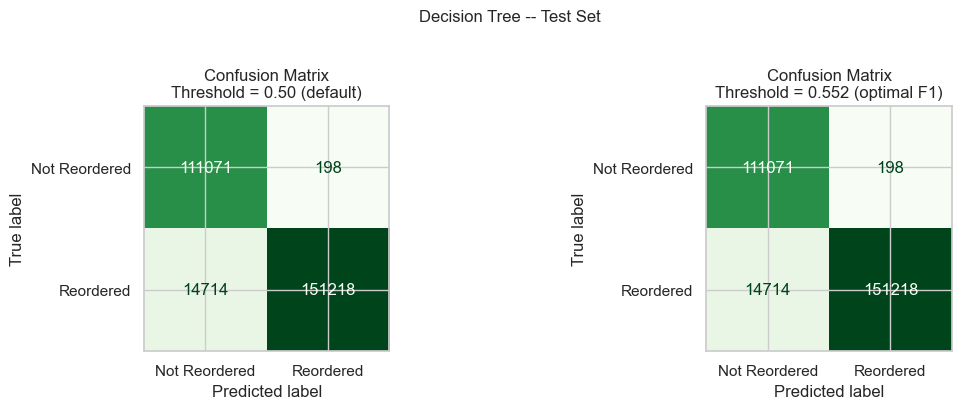

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(
        axes,
        [y_pred_05, y_pred_opt],
        [f'Threshold = 0.50 (default)',
         f'Threshold = {best_threshold:.3f} (optimal F1)']):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Not Reordered', 'Reordered'])
    disp.plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'Confusion Matrix\n{title}')

plt.suptitle('Decision Tree -- Test Set', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


### 5.4 Probability Distribution & Calibration

Decision tree probabilities are inherently discrete -- each leaf node outputs the
fraction of training samples of each class, so the number of unique probability
values equals the number of leaves. This produces a characteristic spiky distribution
rather than the smooth curves seen in Logistic Regression and LightGBM.


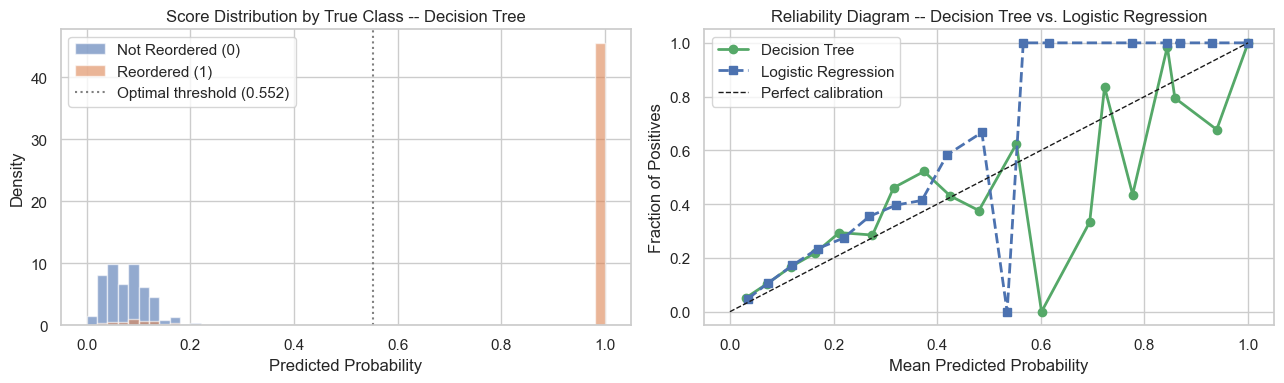

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_prob_best[y_test == 0], bins=50, alpha=0.6,
             color='#4C72B0', label='Not Reordered (0)', density=True)
axes[0].hist(y_prob_best[y_test == 1], bins=50, alpha=0.6,
             color='#DD8452', label='Reordered (1)', density=True)
axes[0].axvline(best_threshold, linestyle=':', color='grey',
                label=f'Optimal threshold ({best_threshold:.3f})')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Distribution by True Class -- Decision Tree')
axes[0].legend()

prob_true_dt, prob_pred_dt = calibration_curve(y_test, y_prob_best, n_bins=20)
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_lr,   n_bins=20)

axes[1].plot(prob_pred_dt, prob_true_dt, 'o-', color='#55A868', lw=2,
             label='Decision Tree')
axes[1].plot(prob_pred_lr, prob_true_lr, 's--', color='#4C72B0', lw=2,
             label='Logistic Regression')
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Reliability Diagram -- Decision Tree vs. Logistic Regression')
axes[1].legend()

plt.tight_layout()
plt.show()


## 6. Tree Visualisation & Interpretation

### 6.1 Shallow Tree (depth=5) -- Full Visualisation

The shallow tree (depth=5) is visualised in full. Each node shows:
- The splitting feature and threshold
- Gini impurity (lower = purer node)
- Number of training samples reaching this node
- Class distribution at this node

This is the primary interpretability deliverable of the decision tree model --
a human-readable set of if/else rules that explains the reorder prediction logic.


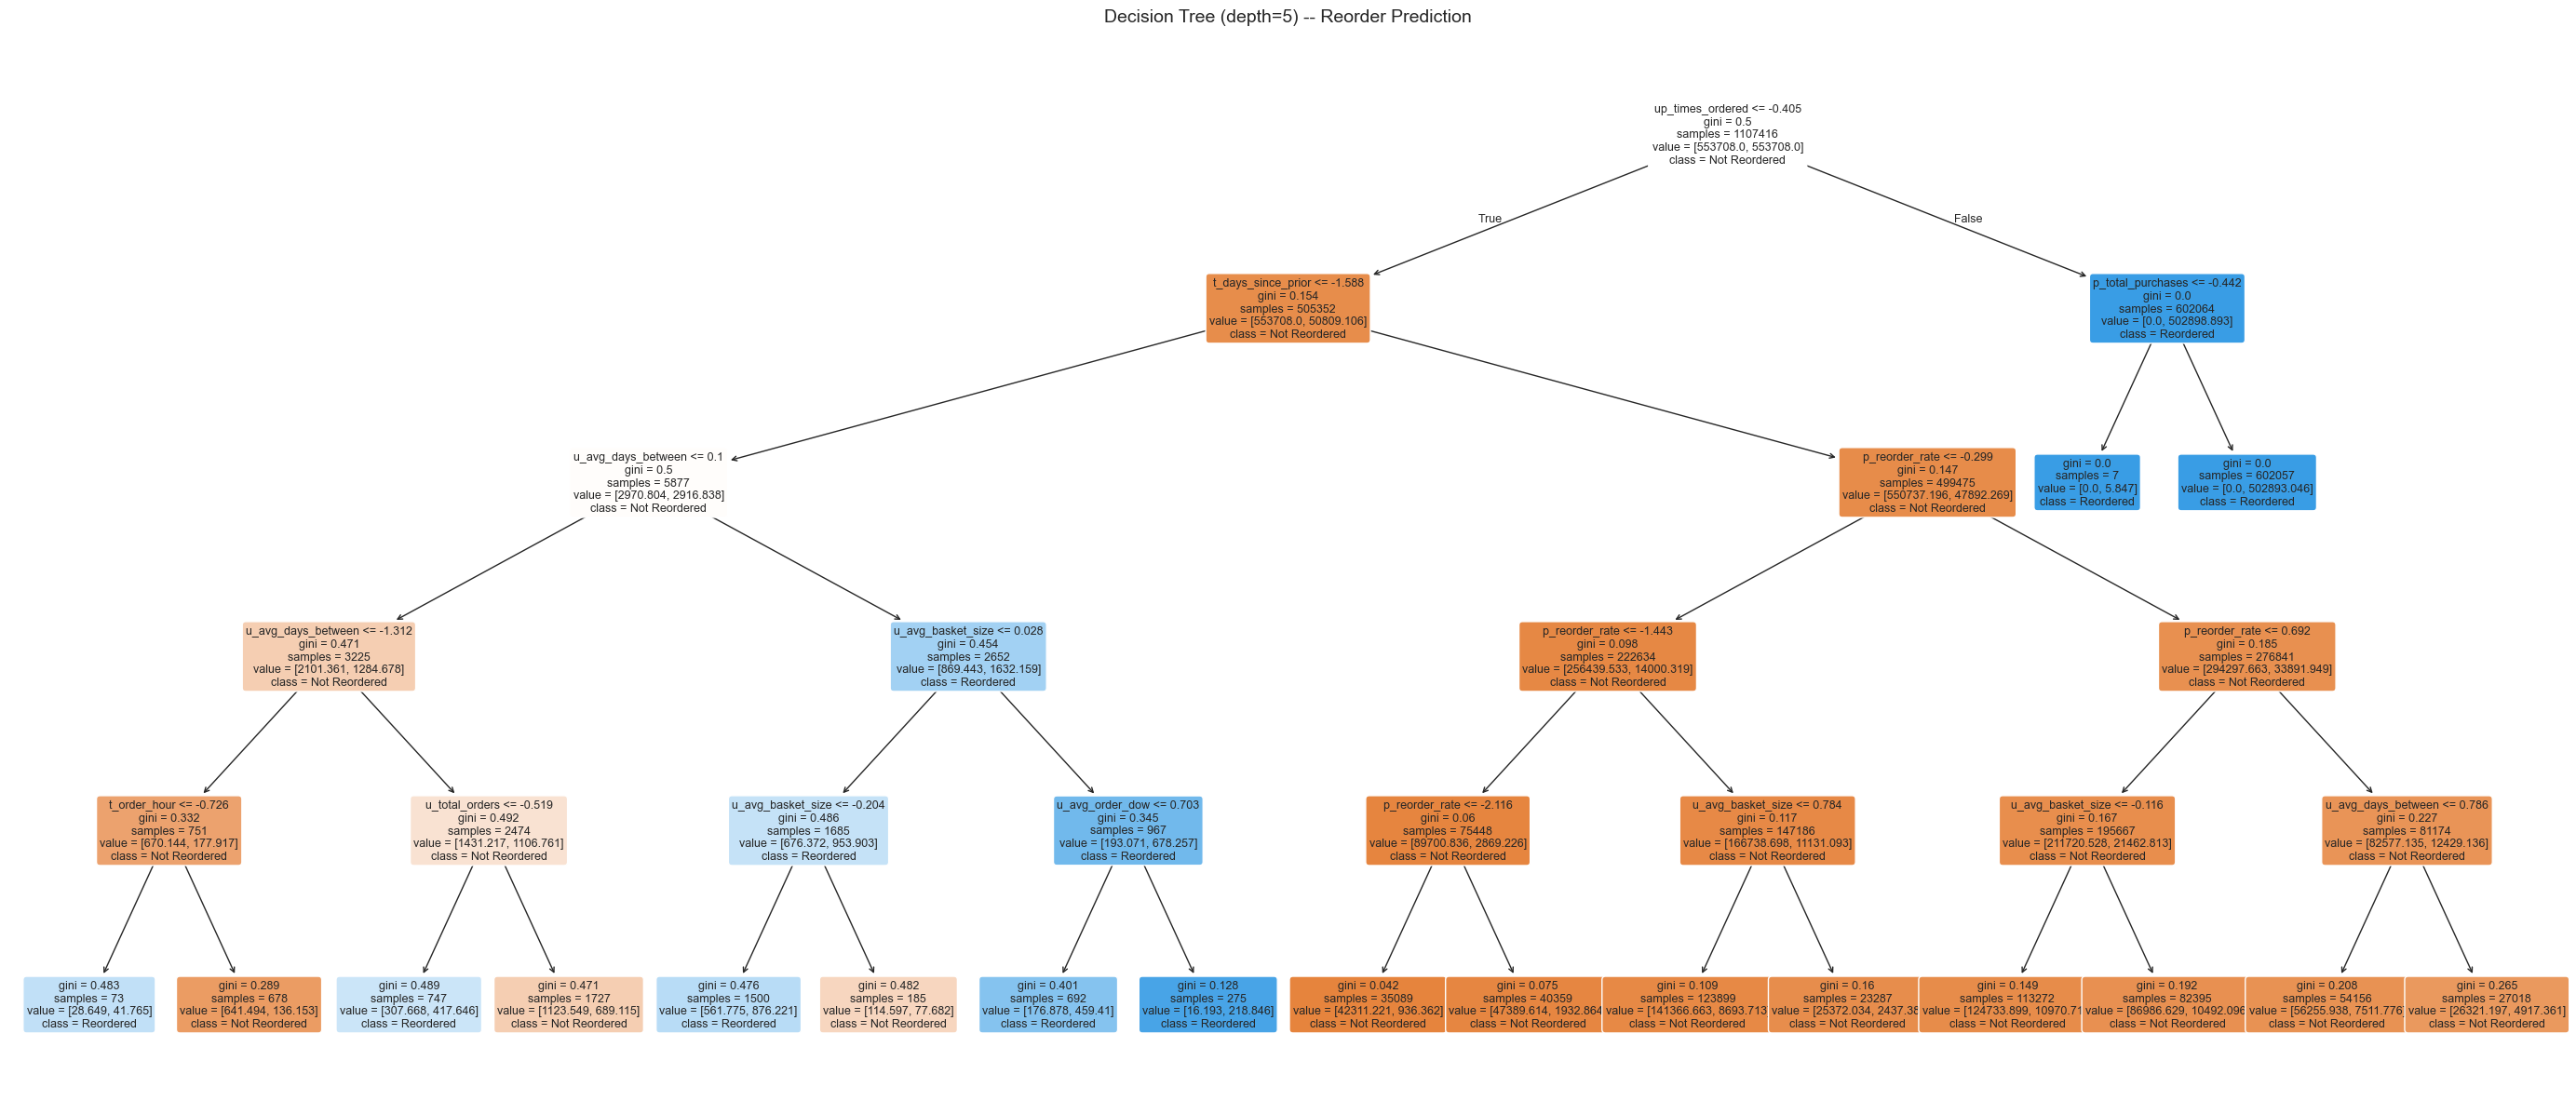

Tree diagram saved to ../models/decision_tree_depth5.png


In [12]:
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    dt_shallow,
    feature_names = FEATURE_COLS_DT,
    class_names   = ['Not Reordered', 'Reordered'],
    filled        = True,
    rounded       = True,
    fontsize      = 9,
    ax            = ax,
    impurity      = True,
    proportion    = False
)
plt.title('Decision Tree (depth=5) -- Reorder Prediction',
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'decision_tree_depth5.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Tree diagram saved to ../models/decision_tree_depth5.png")


### 6.2 Text Rule Export

The shallow tree is also exported as human-readable text rules.
This format is useful for documentation and for explaining the model logic
to a non-technical audience.


In [13]:
rules = export_text(dt_shallow,
                    feature_names=FEATURE_COLS_DT,
                    max_depth=5)
print(rules)


|--- up_times_ordered <= -0.41
|   |--- t_days_since_prior <= -1.59
|   |   |--- u_avg_days_between <= 0.10
|   |   |   |--- u_avg_days_between <= -1.31
|   |   |   |   |--- t_order_hour <= -0.73
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- t_order_hour >  -0.73
|   |   |   |   |   |--- class: 0
|   |   |   |--- u_avg_days_between >  -1.31
|   |   |   |   |--- u_total_orders <= -0.52
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- u_total_orders >  -0.52
|   |   |   |   |   |--- class: 0
|   |   |--- u_avg_days_between >  0.10
|   |   |   |--- u_avg_basket_size <= 0.03
|   |   |   |   |--- u_avg_basket_size <= -0.20
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- u_avg_basket_size >  -0.20
|   |   |   |   |   |--- class: 0
|   |   |   |--- u_avg_basket_size >  0.03
|   |   |   |   |--- u_avg_order_dow <= 0.70
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- u_avg_order_dow >  0.70
|   |   |   |   |   |--- class: 1
|   |--- t_days_since_prior >  -1.59
|   |

## 7. Feature Importance

Decision tree feature importance is measured by the total reduction in Gini
impurity contributed by splits on each feature, normalised so all values sum to 1.
This is analogous to LightGBM's gain importance.

Features that never appear in any split have an importance of 0.


Features used in splits     : 23
Features never used (imp=0) : 3
  Unused: ['p_total_purchases', 'up_reorder_rate', 'up_in_last_order']


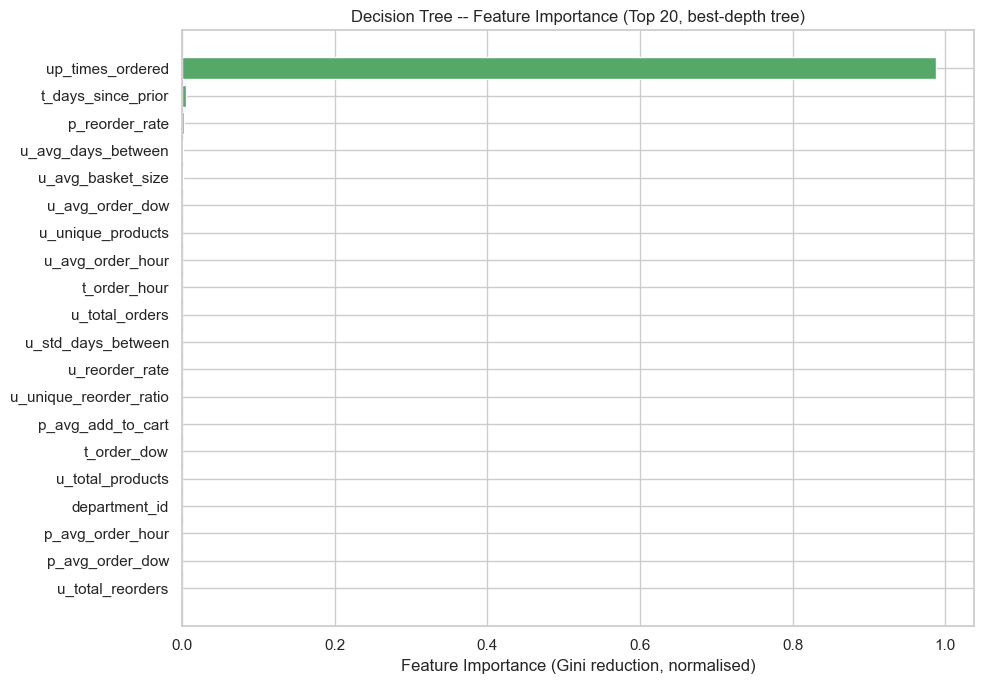


Top 10 features by importance:
           feature  importance
  up_times_ordered    0.988335
t_days_since_prior    0.004859
    p_reorder_rate    0.002658
u_avg_days_between    0.001038
 u_avg_basket_size    0.000926
   u_avg_order_dow    0.000374
 u_unique_products    0.000308
  u_avg_order_hour    0.000276
      t_order_hour    0.000204
    u_total_orders    0.000179


In [14]:
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS_DT,
    'importance': dt_best.feature_importances_
}).sort_values('importance', ascending=False)

# non-zero features only
nonzero = importance_df[importance_df['importance'] > 0]
zero    = importance_df[importance_df['importance'] == 0]

print(f"Features used in splits     : {len(nonzero)}")
print(f"Features never used (imp=0) : {len(zero)}")
if len(zero) > 0:
    print(f"  Unused: {zero['feature'].tolist()}")

plt.figure(figsize=(10, 7))
top = nonzero.head(20)
colors = ['#55A868'] * len(top)
plt.barh(top['feature'], top['importance'], color=colors, edgecolor='white')
plt.xlabel('Feature Importance (Gini reduction, normalised)')
plt.title('Decision Tree -- Feature Importance (Top 20, best-depth tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features by importance:")
print(importance_df.head(10)[['feature','importance']].to_string(index=False))


## 8. Results Summary

In [15]:
results_dt = {
    'Model'              : 'Decision Tree',
    'ROC-AUC'            : round(roc_auc, 4),
    'PR-AUC (Avg Prec)'  : round(avg_prec, 4),
    'Brier Score'        : round(brier, 4),
    'Best Depth'         : best_depth,
    'Optimal Threshold'  : round(best_threshold, 4),
    'F1 (optimal thresh)': round(f1_score(y_test, y_pred_opt), 4),
    'Precision (opt)'    : round(precision_score(y_test, y_pred_opt), 4),
    'Recall (opt)'       : round(recall_score(y_test, y_pred_opt), 4),
    'Accuracy (opt)'     : round(accuracy_score(y_test, y_pred_opt), 4),
    'F1 (0.50 thresh)'   : round(f1_score(y_test, y_pred_05), 4),
}

print("Decision Tree Results")
print("-" * 45)
for k, v in results_dt.items():
    print(f"  {k:<25} : {v}")

print("\nComparison with Logistic Regression")
print("-" * 60)
metrics = ['ROC-AUC', 'PR-AUC (Avg Prec)', 'Brier Score',
           'F1 (optimal thresh)', 'Accuracy (opt)']
for m in metrics:
    dt_val = results_dt[m]
    lr_val = float(lr_results[m].values[0])
    delta  = dt_val - lr_val
    if m == 'Brier Score':
        better = 'Decision Tree' if delta < 0 else 'Logistic Reg'
    else:
        better = 'Decision Tree' if delta > 0 else 'Logistic Reg'
    print(f"  {m:<25} DT={dt_val:.4f}  LR={lr_val:.4f}  "
          f"delta={delta:+.4f}  ({better} wins)")


Decision Tree Results
---------------------------------------------
  Model                     : Decision Tree
  ROC-AUC                   : 0.9685
  PR-AUC (Avg Prec)         : 0.9834
  Brier Score               : 0.0466
  Best Depth                : 9
  Optimal Threshold         : 0.5517
  F1 (optimal thresh)       : 0.953
  Precision (opt)           : 0.9987
  Recall (opt)              : 0.9113
  Accuracy (opt)            : 0.9462
  F1 (0.50 thresh)          : 0.953

Comparison with Logistic Regression
------------------------------------------------------------
  ROC-AUC                   DT=0.9685  LR=0.9689  delta=-0.0004  (Logistic Reg wins)
  PR-AUC (Avg Prec)         DT=0.9834  LR=0.9841  delta=-0.0007  (Logistic Reg wins)
  Brier Score               DT=0.0466  LR=0.0472  delta=-0.0006  (Decision Tree wins)
  F1 (optimal thresh)       DT=0.9530  LR=0.9520  delta=+0.0010  (Decision Tree wins)
  Accuracy (opt)            DT=0.9462  LR=0.9452  delta=+0.0010  (Decision Tree wins)

## 9. Save Model & Results

In [16]:
save_dir = MODEL_DIR
os.makedirs(save_dir, exist_ok=True)

joblib.dump(dt_best,      os.path.join(save_dir, 'dt_best.pkl'))
joblib.dump(dt_shallow,   os.path.join(save_dir, 'dt_shallow.pkl'))
joblib.dump(importance_df, os.path.join(save_dir, 'dt_importance.pkl'))

results_df = pd.DataFrame([results_dt])
results_df.to_csv(os.path.join(save_dir, 'dt_results.csv'), index=False)

print(f"Saved to: {os.path.abspath(save_dir)}")
for fname in ['dt_best.pkl', 'dt_shallow.pkl',
              'dt_importance.pkl', 'dt_results.csv',
              'decision_tree_depth5.png']:
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f"  {fname:<35} {size:>8.2f} MB")


Saved to: /Users/martinmilon/Documents/DTSC870/models
  dt_best.pkl                             0.04 MB
  dt_shallow.pkl                          0.00 MB
  dt_importance.pkl                       0.00 MB
  dt_results.csv                          0.00 MB
  decision_tree_depth5.png                0.69 MB


## 10. Key Takeaways & Handoff to Step 7

### Interpreting these results

**Performance vs. interpretability tradeoff:**
The decision tree sits in a specific position in our model lineup. If it performs
comparably to Logistic Regression on ROC-AUC, it offers a compelling argument:
similar predictive power but with explicit, human-readable decision rules that
explain every prediction. If it underperforms Logistic Regression, that is also
informative -- it tells us that the linear boundary Logistic Regression draws is
a better approximation of the true decision boundary than a single tree can produce
at any reasonable depth.

**Depth and the overfitting curve:**
The depth analysis in Section 3 shows exactly where the model transitions from
underfitting (too shallow to capture the signal) to overfitting (too deep,
memorising noise). The gap between train AUC and CV AUC at deeper depths is
the visual signature of overfitting -- worth noting in Step 7.

**Probability discreteness:**
The spiky calibration curve and discrete probability distribution (Section 5.4)
are inherent to decision trees. Each leaf outputs a fixed probability, so the
model cannot produce the smooth probability gradations that Logistic Regression
and LightGBM do. This is relevant for deployment contexts where calibrated
probabilities matter (e.g. ranking users by reorder likelihood for a marketing
campaign).

**Feature importance vs. other models:**
Comparing the decision tree's feature importance with LightGBM's gain importance
(Step 6) reveals which features are consistently important across model types --
a sign of robust, genuine signal -- versus features that are important in one
model but not another, which may reflect model-specific biases.

### Artefacts saved to `../models/`

| File | Description |
|---|---|
| `dt_best.pkl` | Fitted DecisionTreeClassifier at optimal depth |
| `dt_shallow.pkl` | Fitted DecisionTreeClassifier at depth=5 (for visualisation) |
| `dt_importance.pkl` | Feature importance dataframe |
| `dt_results.csv` | Metrics summary -- loaded by Step 7 for three-way comparison |
| `decision_tree_depth5.png` | Tree diagram image |
